In [2]:
import numpy as np
import chipwhisperer as cw
import chipwhisperer.analyzer as cwa
from chipwhisperer.analyzer.attacks.models.aes.key_schedule import key_schedule_rounds
import os
import numpy as np
import matplotlib.pyplot as plt

## Intialize ChipWhisperer Analyzer Module

In [3]:
# Load data file
data = np.load("data/traces_1.npz", allow_pickle=True)
plaintexts = data['dut_io_data'][:950]
ciphertexts = data['dut_io_computed_data'][:950]
traces = data['wave'][:950]

print(data.files)
print(f"dtype of traces is {ciphertexts.dtype}")
print(f"dtype of traces is {traces.dtype}")
print(f"Shape of traces captured is {traces.shape}")
print(f"Shape of ciphertext data is {ciphertexts.shape}")
print(f"Shape of plaintext data is {plaintexts.shape}")
print(f"Single trace is {len(traces[120])}")
print(f"Single ciphertext is {ciphertexts[50]}")

['wave', 'dut_io_data', 'dut_io_computed_data']
dtype of traces is int32
dtype of traces is float64
Shape of traces captured is (950, 200)
Shape of ciphertext data is (950, 16)
Shape of plaintext data is (950, 16)
Single trace is 200
Single ciphertext is [132 118 135 140 223 136 219 205  70 230 105 219 236  25  45   1]


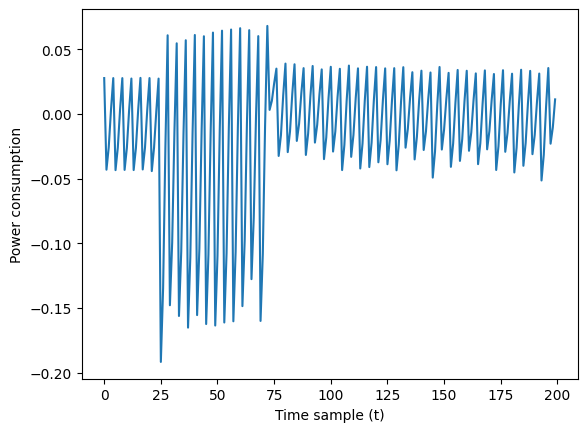

In [4]:
# Average all traces to reduce noise
avg_trace = np.mean(traces, axis=0)

# Plot the averaged trace
plt.plot(avg_trace)
plt.xlabel("Time sample (t)")
plt.ylabel("Power consumption")
plt.show()

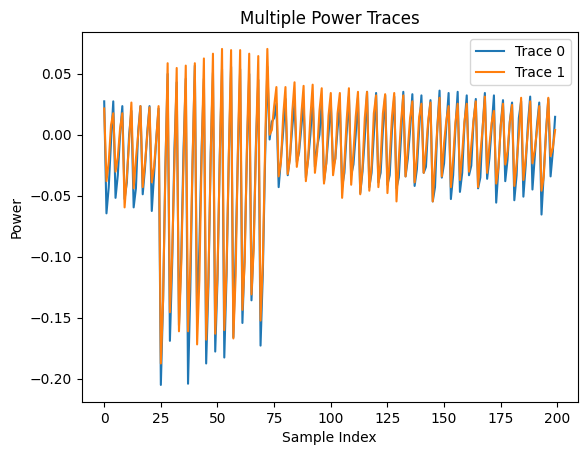

In [5]:
# multiple traces
for i in range(2):  # Plot first 2 traces
    plt.plot(traces[i], label=f"Trace {i}")
plt.legend()
plt.title("Multiple Power Traces")
plt.xlabel("Sample Index")
plt.ylabel("Power")
plt.show()

[INFO] Calculating NSR for 950 traces with 200 samples each
[RESULT] Overall NSR (linear): 0.307647
[RESULT] Overall NSR (dB): -5.12 dB
[RESULT] Overall SNR (linear): 3.250473
[RESULT] Overall SNR (dB): 5.12 dB


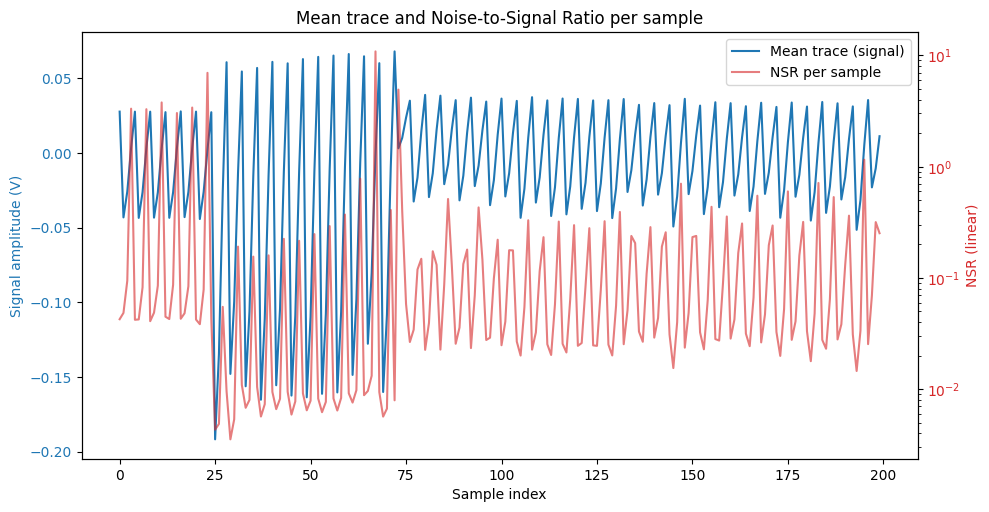

In [6]:
def compute_and_plot_nsr(traces: np.ndarray, save_path: str | None = None):
    """
    Compute noise-to-signal ratio (NSR) for a set of aligned traces, and plot results.
    
    Parameters
    ----------
    traces : np.ndarray
        2D array of shape (n_traces, n_samples) containing aligned, scaled traces in volts.
    save_path : str or None
        If provided, path to save the plot (PNG). If None, plot is just shown.
    
    Returns
    -------
    nsr_per_sample : np.ndarray
        NSR (noise variance / signal variance) for each sample index.
    overall_nsr : float
        Average NSR across all sample points (linear scale).
    """
    if traces.ndim != 2:
        raise ValueError("Expected traces as 2D array (n_traces, n_samples)")

    n_traces, n_samples = traces.shape
    print(f"[INFO] Calculating NSR for {n_traces} traces with {n_samples} samples each")

    # Step 1: Compute the deterministic signal = mean waveform
    mean_trace = np.mean(traces, axis=0)

    # Step 2: Compute signal variance (variance of mean trace over time)
    # Note: Here "signal variance" is computed across time, not across traces
    signal_variance_per_sample = mean_trace**2  # squared mean = power at each point

    # Step 3: Compute noise variance = mean over traces of (trace - mean_trace)^2
    noise_variance_per_sample = np.mean((traces - mean_trace)**2, axis=0)

    # Step 4: NSR = noise variance / signal variance (avoid div-by-zero)
    # If signal variance is 0, set NSR to np.inf (pure noise)
    with np.errstate(divide='ignore', invalid='ignore'):
        nsr_per_sample = np.where(signal_variance_per_sample > 0,
                                  noise_variance_per_sample / signal_variance_per_sample,
                                  np.inf)

    # Step 5: Compute overall NSR (mean over samples, ignoring infinities)
    finite_nsr = nsr_per_sample[np.isfinite(nsr_per_sample)]
    overall_nsr = np.mean(finite_nsr)
    overall_snr = 1.0 / overall_nsr if overall_nsr != 0 else np.inf

    # Print results in linear and dB scale
    print(f"[RESULT] Overall NSR (linear): {overall_nsr:.6f}")
    print(f"[RESULT] Overall NSR (dB): {10*np.log10(overall_nsr):.2f} dB")
    print(f"[RESULT] Overall SNR (linear): {overall_snr:.6f}")
    print(f"[RESULT] Overall SNR (dB): {10*np.log10(overall_snr):.2f} dB")

    # Step 6: Plot
    fig, ax1 = plt.subplots(figsize=(10, 5))
    t_axis = np.arange(n_samples)  # sample index; replace with time scale if available

    color_signal = 'tab:blue'
    color_nsr = 'tab:red'

    ax1.set_xlabel("Sample index")
    ax1.set_ylabel("Signal amplitude (V)", color=color_signal)
    ax1.plot(t_axis, mean_trace, color=color_signal, label="Mean trace (signal)")
    ax1.tick_params(axis='y', labelcolor=color_signal)

    ax2 = ax1.twinx()
    ax2.set_ylabel("NSR (linear)", color=color_nsr)
    ax2.plot(t_axis, nsr_per_sample, color=color_nsr, alpha=0.6, label="NSR per sample")
    ax2.tick_params(axis='y', labelcolor=color_nsr)
    ax2.set_yscale('log')  # log scale helps visualize small and large NSR

    fig.tight_layout()
    plt.title("Mean trace and Noise-to-Signal Ratio per sample")

    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"[INFO] NSR plot saved to {save_path}")
    else:
        plt.show()

    return nsr_per_sample, overall_nsr

# usage:
nsr_curve, avg_nsr = compute_and_plot_nsr(traces)


In [7]:
# Create a dummy key of the same length
key_placeholder = bytearray(16)

# Create the CW project and append traces
# Make sure the 'data/traces_1' directory exists
if not os.path.exists("data/traces_1"):
    os.makedirs("data/traces_1")
    
proj = cw.create_project("data/traces_1/CW_305.cwp", overwrite=True)

print("Processing and appending traces to the project...")
for i, (wave, pt_raw, ct_raw) in enumerate(zip(traces, plaintexts, ciphertexts)):
    pt = pt_raw
    ct = ct_raw
    
    # Sanity check: ensure all blocks have the correct fixed length
    assert len(pt) == 16 and len(ct) == 16, \
           f"Trace {i}: Got pt/ct lengths {len(pt)}/{len(ct)}, expected {16}"
           
    proj.traces.append(cw.Trace(wave, pt, ct, key_placeholder))

print(f"Successfully processed {len(proj.traces)} traces.")
#proj.save()  # save the project for later use


Processing and appending traces to the project...
Successfully processed 950 traces.


### Perform a CPA attack on the Last round

In [8]:
print("Instantiating and running CPA attack...")
# Set leakage model:
leak_model = cwa.leakage_models.last_round_state_diff
# Instantiate and run CPA
attack = cwa.cpa(proj, leak_model)
cb = cwa.get_jupyter_callback(attack)
best_guesses = attack.run(cb)

print("\n--- Attack Results ---")
print("Recovered key-byte guesses:", best_guesses)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
PGE=,119,31,41,38,161,227,3,137,85,157,212,239,20,172,225,93
0,D50.179,5E0.164,840.180,A70.234,430.195,250.168,200.142,BC0.168,C00.145,240.194,830.156,880.169,1D0.174,150.150,880.166,000.153
1,710.141,EC0.133,100.150,CA0.126,8A0.156,6C0.137,6C0.130,3D0.130,BC0.129,170.136,F50.129,990.152,720.126,C50.145,4C0.140,960.134
2,E80.133,3A0.130,1B0.123,C30.120,F00.136,4F0.129,7D0.118,2E0.128,EA0.127,0B0.124,000.123,F70.136,E00.121,730.129,3F0.134,E90.129
3,DB0.127,650.127,7B0.122,D10.119,E40.134,B80.122,E20.113,0D0.123,EF0.126,C00.123,670.117,190.133,850.119,E20.128,3D0.131,030.126
4,F20.125,7A0.127,540.119,B30.119,420.134,570.118,9C0.113,080.121,5A0.121,3C0.118,350.117,E20.128,480.117,120.125,CF0.126,090.126



--- Attack Results ---
Recovered key-byte guesses: Subkey KGuess Correlation
  00    0xD5    0.17868
  01    0x5E    0.16433
  02    0x84    0.18034
  03    0xA7    0.23423
  04    0x43    0.19498
  05    0x25    0.16768
  06    0x20    0.14223
  07    0xBC    0.16772
  08    0xC0    0.14519
  09    0x24    0.19387
  10    0x83    0.15594
  11    0x88    0.16921
  12    0x1D    0.17373
  13    0x15    0.14990
  14    0x88    0.16625
  15    0x00    0.15325



### Perform reverse schedule operation to recover the real Key

In [9]:
recv_lastroundkey = [kguess[0][0] for kguess in best_guesses.find_maximums()]
recv_key = key_schedule_rounds(recv_lastroundkey, 10, 0)
for subkey in recv_key:
    print(hex(subkey), end="")

0x100xa50x880x690xd70x4b0xe50xa30x740xcf0x860x7c0xfb0x470x380x59

In [10]:
key = "0x100xa50x880x690xd70x4b0xe50xa30x740xcf0x860x7c0xfb0x470x380x59"